# Ring Negative Visualization

Shows the tile-level ring computed from **eroded** vs **original** inklabels.

Key question: how many ring negatives contain REAL ink (false negative labels)?

In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches

scroll = 20230827161847
T = 32

eroded = cv2.imread(f'./eroded_inklabels/{scroll}.png', cv2.IMREAD_GRAYSCALE) / 255.0
orig   = cv2.imread(f'./inklabels/{scroll}.png',        cv2.IMREAD_GRAYSCALE) / 255.0
mask   = cv2.imread(f'./masks/{scroll}.png',            cv2.IMREAD_GRAYSCALE) / 255.0

print(f'eroded: {eroded.shape}  orig: {orig.shape}  mask: {mask.shape}')

# crop to shared dimensions
h = min(eroded.shape[0], orig.shape[0], mask.shape[0])
w = min(eroded.shape[1], orig.shape[1], mask.shape[1])
eroded = eroded[:h, :w]
orig   = orig[:h, :w]
mask   = mask[:h, :w]

eroded: (9216, 5120)  orig: (9216, 5120)  mask: (9163, 5048)


In [2]:
def build_tile_ring(label_img, mask_img, radius=2):
    """compute tile-level ring using label_img to define ink tiles."""
    n_ty, n_tx = h // T, w // T
    ink_tile  = np.zeros((n_ty, n_tx), np.uint8)
    mask_tile = np.zeros((n_ty, n_tx), np.uint8)
    for ty in range(n_ty):
        for tx in range(n_tx):
            if np.any(label_img[ty*T:(ty+1)*T, tx*T:(tx+1)*T] > 0.5): ink_tile[ty, tx] = 1
            if np.any(mask_img[ ty*T:(ty+1)*T, tx*T:(tx+1)*T] > 0.5): mask_tile[ty, tx] = 1
    k = 2 * radius + 1
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    dilated = cv2.dilate(ink_tile, kernel)
    ring    = ((dilated - ink_tile) > 0) & (mask_tile > 0)
    return ink_tile, ring

ink_ero, ring_ero  = build_tile_ring(eroded, mask)
ink_orig, ring_orig = build_tile_ring(orig, mask)

print(f'ERODED labels:   ink_tiles={ink_ero.sum()}, ring_tiles={ring_ero.sum()}')
print(f'ORIGINAL labels: ink_tiles={ink_orig.sum()}, ring_tiles={ring_orig.sum()}')

ERODED labels:   ink_tiles=3883, ring_tiles=5070
ORIGINAL labels: ink_tiles=4946, ring_tiles=4821


In [3]:
def check_contamination(ring, check_labels, label_name):
    """how many ring tiles contain ink according to check_labels?"""
    n_ty, n_tx = h // T, w // T
    contaminated = 0
    for ty in range(n_ty):
        for tx in range(n_tx):
            if ring[ty, tx] and np.any(check_labels[ty*T:(ty+1)*T, tx*T:(tx+1)*T] > 0.5):
                contaminated += 1
    pct = 100 * contaminated / max(ring.sum(), 1)
    print(f'Ring contamination by {label_name}: {contaminated}/{ring.sum()} = {pct:.1f}%')
    return contaminated

print('=== ERODED ring ===')
check_contamination(ring_ero, eroded, 'eroded_labels')  # trivially ~0
check_contamination(ring_ero, orig,   'original_labels')  # THE REAL BUG

print('\n=== ORIGINAL ring (proposed fix) ===')
check_contamination(ring_orig, orig,   'original_labels')  # should be ~0
check_contamination(ring_orig, eroded, 'eroded_labels')

=== ERODED ring ===
Ring contamination by eroded_labels: 0/5070 = 0.0%
Ring contamination by original_labels: 1062/5070 = 20.9%

=== ORIGINAL ring (proposed fix) ===
Ring contamination by original_labels: 0/4821 = 0.0%
Ring contamination by eroded_labels: 0/4821 = 0.0%


0

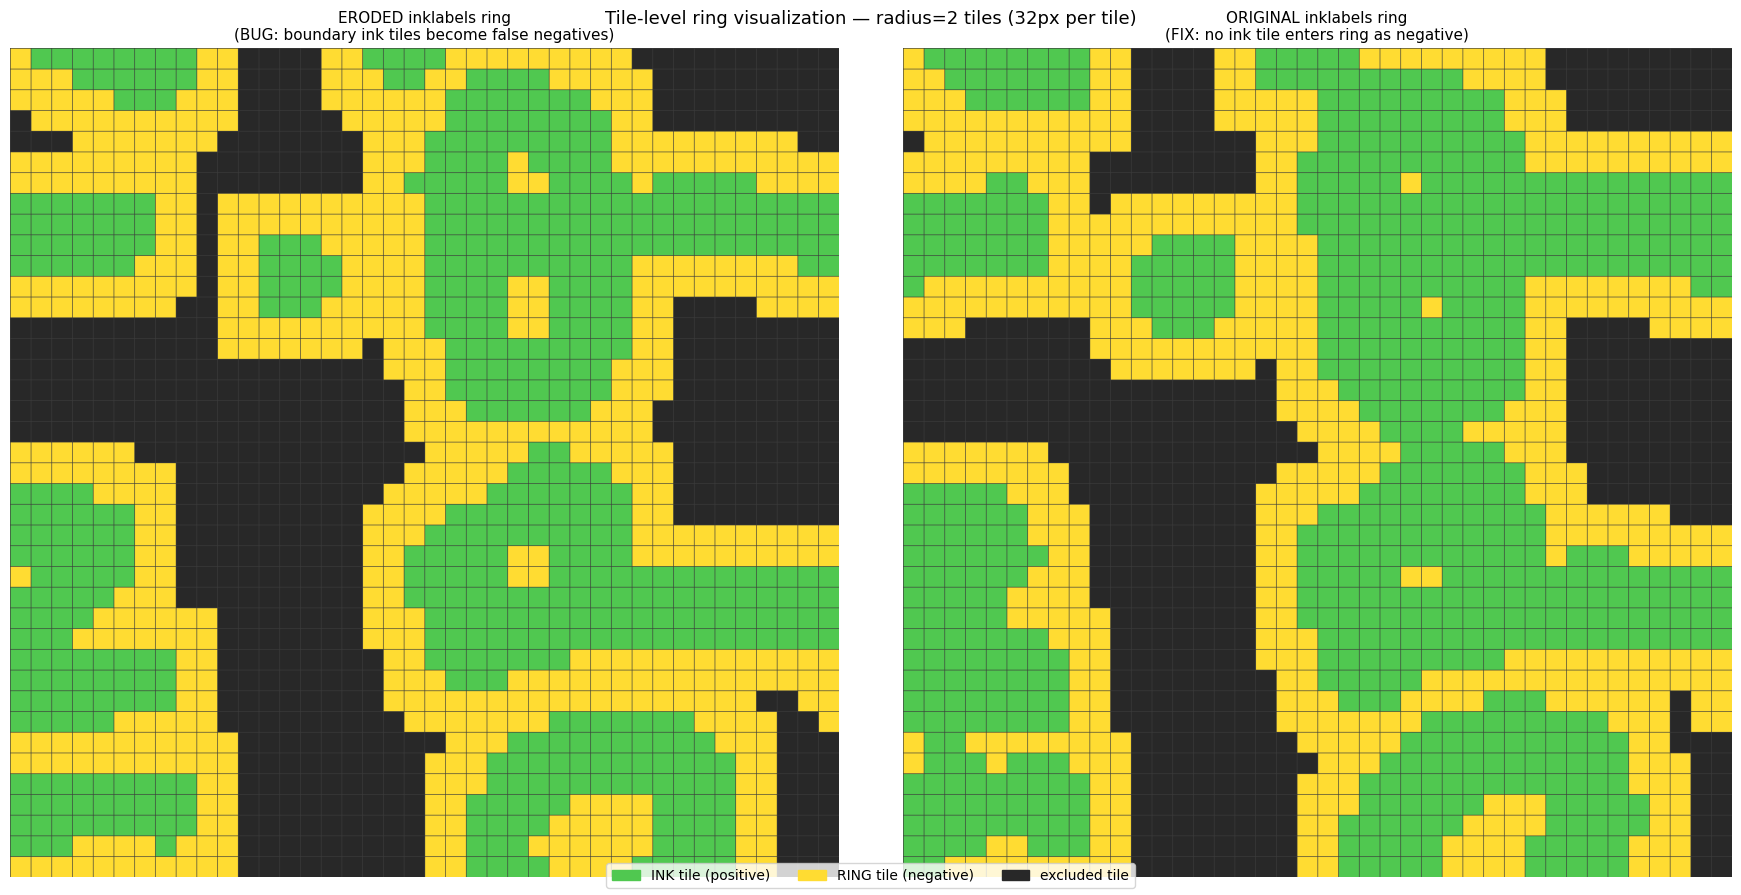

In [9]:
# zoomed-in visual comparison of a single letter region
# find a tile with eroded ink near the top-left of the scroll
n_ty, n_tx = h // T, w // T
# find center of mass of eroded ink tiles
ys, xs = np.where(ink_ero > 0)
cy, cx = int(ys.mean()), int(xs.mean())
# zoom window: ±30 tiles around center
y0, y1 = max(0, cy-20), min(n_ty, cy+20)
x0, x1 = max(0, cx-20), min(n_tx, cx+20)

def make_rgb_map(ink_t, ring_t, y0, y1, x0, x1):
    """make RGB: green=ink, yellow=ring, white=mask-only, gray=outside mask"""
    img = np.full(((y1-y0)*T, (x1-x0)*T, 3), 40, np.uint8)  # dark gray background
    for ty in range(y0, y1):
        for tx in range(x0, x1):
            py, px = (ty-y0)*T, (tx-x0)*T
            if ink_t[ty, tx]:   img[py:py+T, px:px+T] = [80, 200, 80]   # green = ink/positive
            elif ring_t[ty, tx]: img[py:py+T, px:px+T] = [255, 220, 50]  # yellow = ring negative
    # draw tile grid
    for i in range(0, img.shape[0], T): img[i, :] = [60, 60, 60]
    for j in range(0, img.shape[1], T): img[:, j] = [60, 60, 60]
    return img

rgb_ero  = make_rgb_map(ink_ero,  ring_ero,  y0, y1, x0, x1)
rgb_orig = make_rgb_map(ink_orig, ring_orig, y0, y1, x0, x1)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, rgb, title in zip(axes, [rgb_ero, rgb_orig],
        ['ERODED inklabels ring\n(BUG: boundary ink tiles become false negatives)',
         'ORIGINAL inklabels ring\n(FIX: no ink tile enters ring as negative)']):
    ax.imshow(rgb)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

patches = [
    mpatches.Patch(color=[80/255,200/255,80/255], label='INK tile (positive)'),
    mpatches.Patch(color=[255/255,220/255,50/255], label='RING tile (negative)'),
    mpatches.Patch(color=[40/255,40/255,40/255], label='excluded tile'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10)
plt.suptitle(f'Tile-level ring visualization — radius=2 tiles ({T}px per tile)', fontsize=13)
plt.tight_layout()
plt.show()

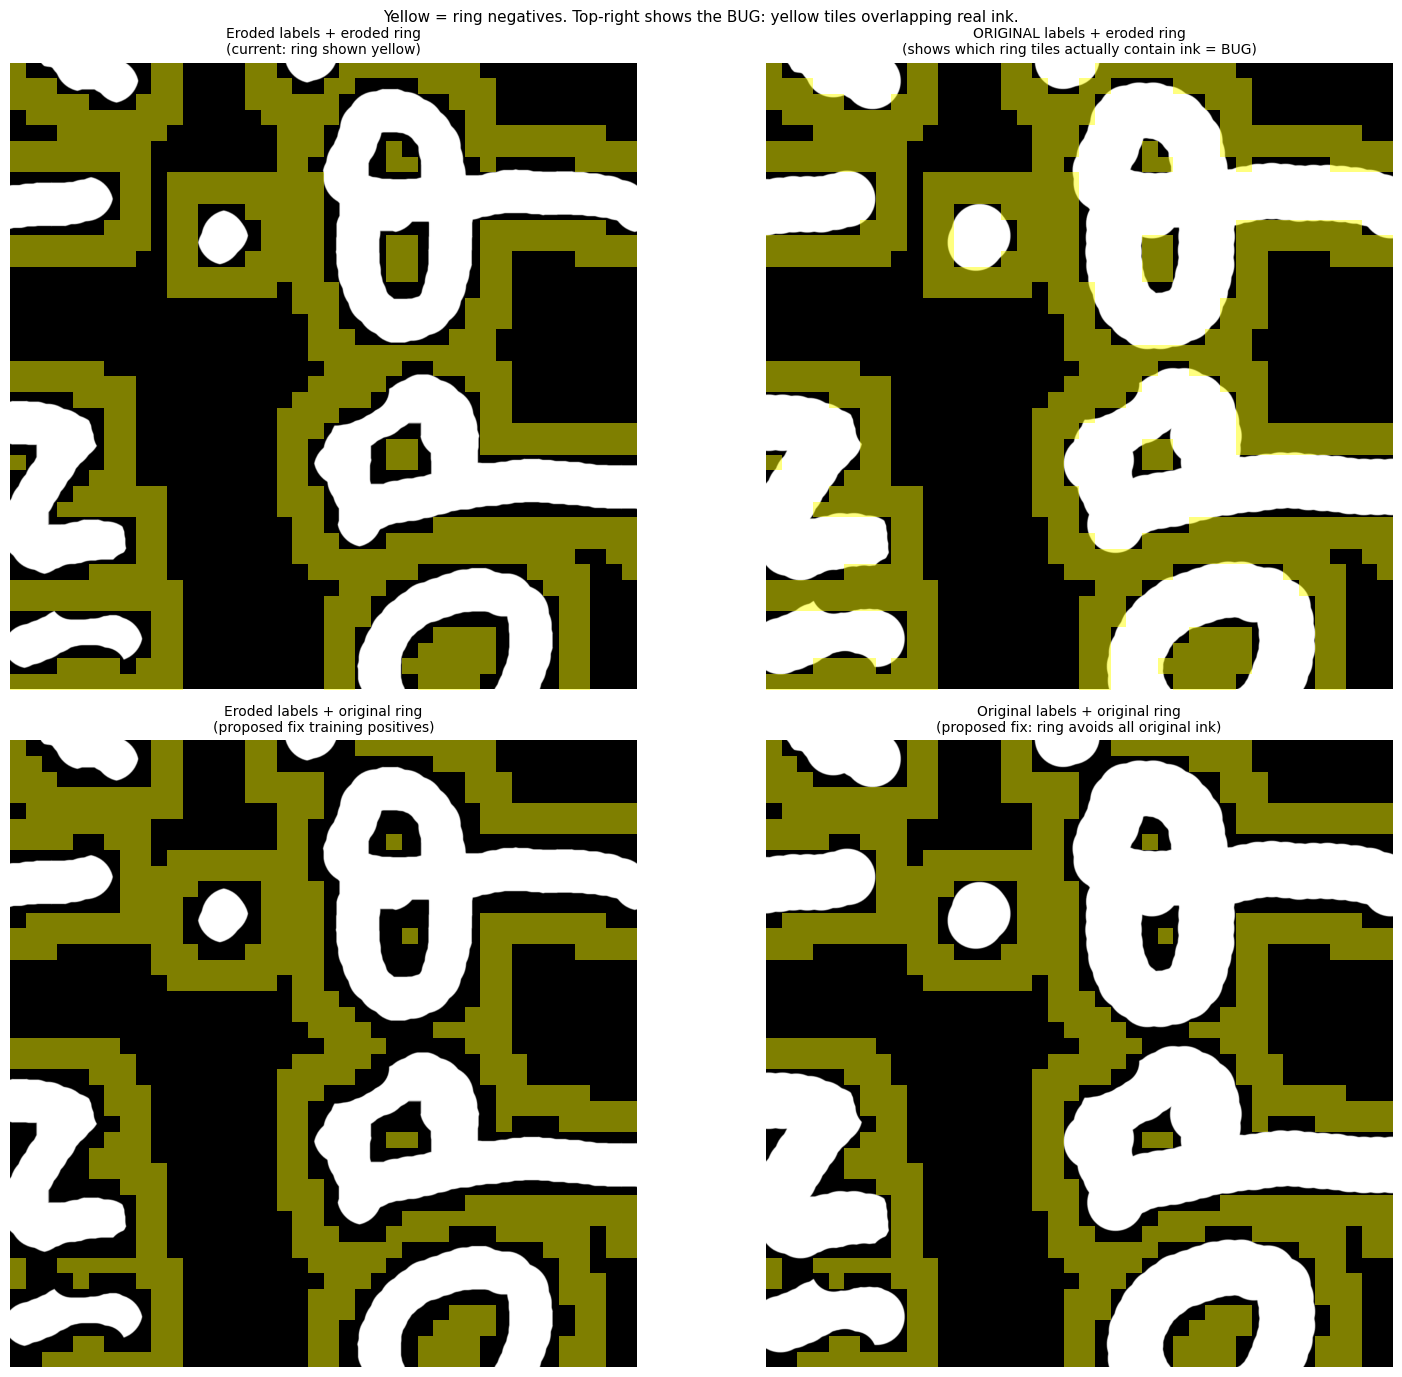

In [5]:
# overlay on the actual label images to see which tiles are affected
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

zoom_px = (y0*T, y1*T, x0*T, x1*T)  # pixel coords of zoomed region

def overlay_ring(label_px, ring_t, ax, title):
    """show label image with ring overlay"""
    y0p, y1p, x0p, x1p = zoom_px
    lbl_crop = label_px[y0p:y1p, x0p:x1p]
    ax.imshow(lbl_crop, cmap='gray', vmin=0, vmax=1)
    # overlay ring tiles as yellow semitransparent boxes
    for ty in range(y0, y1):
        for tx in range(x0, x1):
            if ring_t[ty, tx]:
                py, px = (ty-y0)*T, (tx-x0)*T
                rect = plt.Rectangle((px, py), T, T, lw=0, facecolor='yellow', alpha=0.5)
                ax.add_patch(rect)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

overlay_ring(eroded, ring_ero,  axes[0,0], 'Eroded labels + eroded ring\n(current: ring shown yellow)')
overlay_ring(orig,   ring_ero,  axes[0,1], 'ORIGINAL labels + eroded ring\n(shows which ring tiles actually contain ink = BUG)')
overlay_ring(eroded, ring_orig, axes[1,0], 'Eroded labels + original ring\n(proposed fix training positives)')
overlay_ring(orig,   ring_orig, axes[1,1], 'Original labels + original ring\n(proposed fix: ring avoids all original ink)')

plt.suptitle('Yellow = ring negatives. Top-right shows the BUG: yellow tiles overlapping real ink.', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:

# Third variant: CLOSED ring with explicit air gap
#
# Three separate operations:
#   1. CLOSE: dilate+erode original ink by CLOSE_R tiles → fills interior holes in letters
#   2. AIR GAP: dilate closed region by GAP_R tiles → exclusion zone, ring cannot be here
#   3. RING SHELL: thin ring just outside the air gap → guaranteed clean negatives
#
# The ring tile is at distance >= GAP_R tiles from any original ink pixel.

target_ink = ink_ero.sum()
n_ty, n_tx = h // T, w // T

mask_tile_all = np.zeros((n_ty, n_tx), np.uint8)
for ty in range(n_ty):
    for tx in range(n_tx):
        if np.any(mask[ty*T:(ty+1)*T, tx*T:(tx+1)*T] > 0.5):
            mask_tile_all[ty, tx] = 1

# step 1: close letter interiors (mild — just enough to fill holes between strokes)
CLOSE_R = 3
k_close = 2 * CLOSE_R + 1
kern_close = cv2.getStructuringElement(cv2.MORPH_RECT, (k_close, k_close))
ink_closed = cv2.erode(cv2.dilate(ink_orig, kern_close), kern_close) & mask_tile_all

# step 2: add air gap — push ring starting point away from ink edge
# search for smallest GAP_R that still leaves room for ring >= target_ink
print(f'target ink tiles (eroded): {target_ink}')
print(f'{"GAP_R":>7} {"exclusion":>11} {"ring_r":>7} {"ring_tiles":>11} {"ratio":>7}')

best_GAP_R = 1
ring_closed = None
for GAP_R in range(1, 10):
    k_gap = 2 * GAP_R + 1
    kern_gap = cv2.getStructuringElement(cv2.MORPH_RECT, (k_gap, k_gap))
    exclusion = cv2.dilate(ink_closed, kern_gap) & mask_tile_all  # ink + air gap

    # binary search ring shell width to hit target ratio
    lo, hi, best_r, best_ring = 1, 15, 1, None
    while lo <= hi:
        mid = (lo + hi) // 2
        km = 2 * mid + 1
        krn = cv2.getStructuringElement(cv2.MORPH_RECT, (km, km))
        dil = cv2.dilate(exclusion, krn)
        ring = ((dil - exclusion) > 0) & (mask_tile_all > 0)
        if ring.sum() >= target_ink:
            best_r = mid; best_ring = ring; hi = mid - 1
        else:
            lo = mid + 1

    ring_n = int(best_ring.sum()) if best_ring is not None else 0
    ratio  = ring_n / max(target_ink, 1)
    print(f'{GAP_R:>7} {exclusion.sum():>11} {best_r:>7} {ring_n:>11} {ratio:>7.2f}')

    # pick the smallest GAP_R that achieves ratio within [0.9, 1.2]
    if 0.9 <= ratio <= 1.2 and best_ring is not None:
        best_GAP_R = GAP_R
        ring_closed = best_ring
        exclusion_final = exclusion
        best_ring_r = best_r
        break

if ring_closed is None:
    # fall back: use GAP_R=1 with whatever ring we get
    best_GAP_R, best_ring_r = 1, 2
    k_gap = 3; kern_gap = cv2.getStructuringElement(cv2.MORPH_RECT, (k_gap, k_gap))
    exclusion_final = cv2.dilate(ink_closed, kern_gap) & mask_tile_all
    k2 = 5; kern2 = cv2.getStructuringElement(cv2.MORPH_RECT, (k2, k2))
    dil = cv2.dilate(exclusion_final, kern2)
    ring_closed = ((dil - exclusion_final) > 0) & (mask_tile_all > 0)

ring_closed_count = int(ring_closed.sum())
cont = sum(1 for ty in range(n_ty) for tx in range(n_tx)
    if ring_closed[ty, tx] and np.any(orig[ty*T:(ty+1)*T, tx*T:(tx+1)*T] > 0.5))

print(f'\nSelected: CLOSE_R={CLOSE_R} GAP_R={best_GAP_R} ring_r={best_ring_r}')
print(f'ink_closed={ink_closed.sum()}  exclusion={exclusion_final.sum()}  ring={ring_closed_count}')
print(f'ratio={ring_closed_count/target_ink:.2f}  contamination={cont/max(ring_closed_count,1)*100:.1f}%')
GAP_R = best_GAP_R


target ink tiles (eroded): 3883
  GAP_R   exclusion  ring_r  ring_tiles   ratio
      1        8366       3        4731    1.22
      2        9968       3        4500    1.16

Selected: CLOSE_R=3 GAP_R=2 ring_r=3
ink_closed=6750  exclusion=9968  ring=4500
ratio=1.16  contamination=0.0%


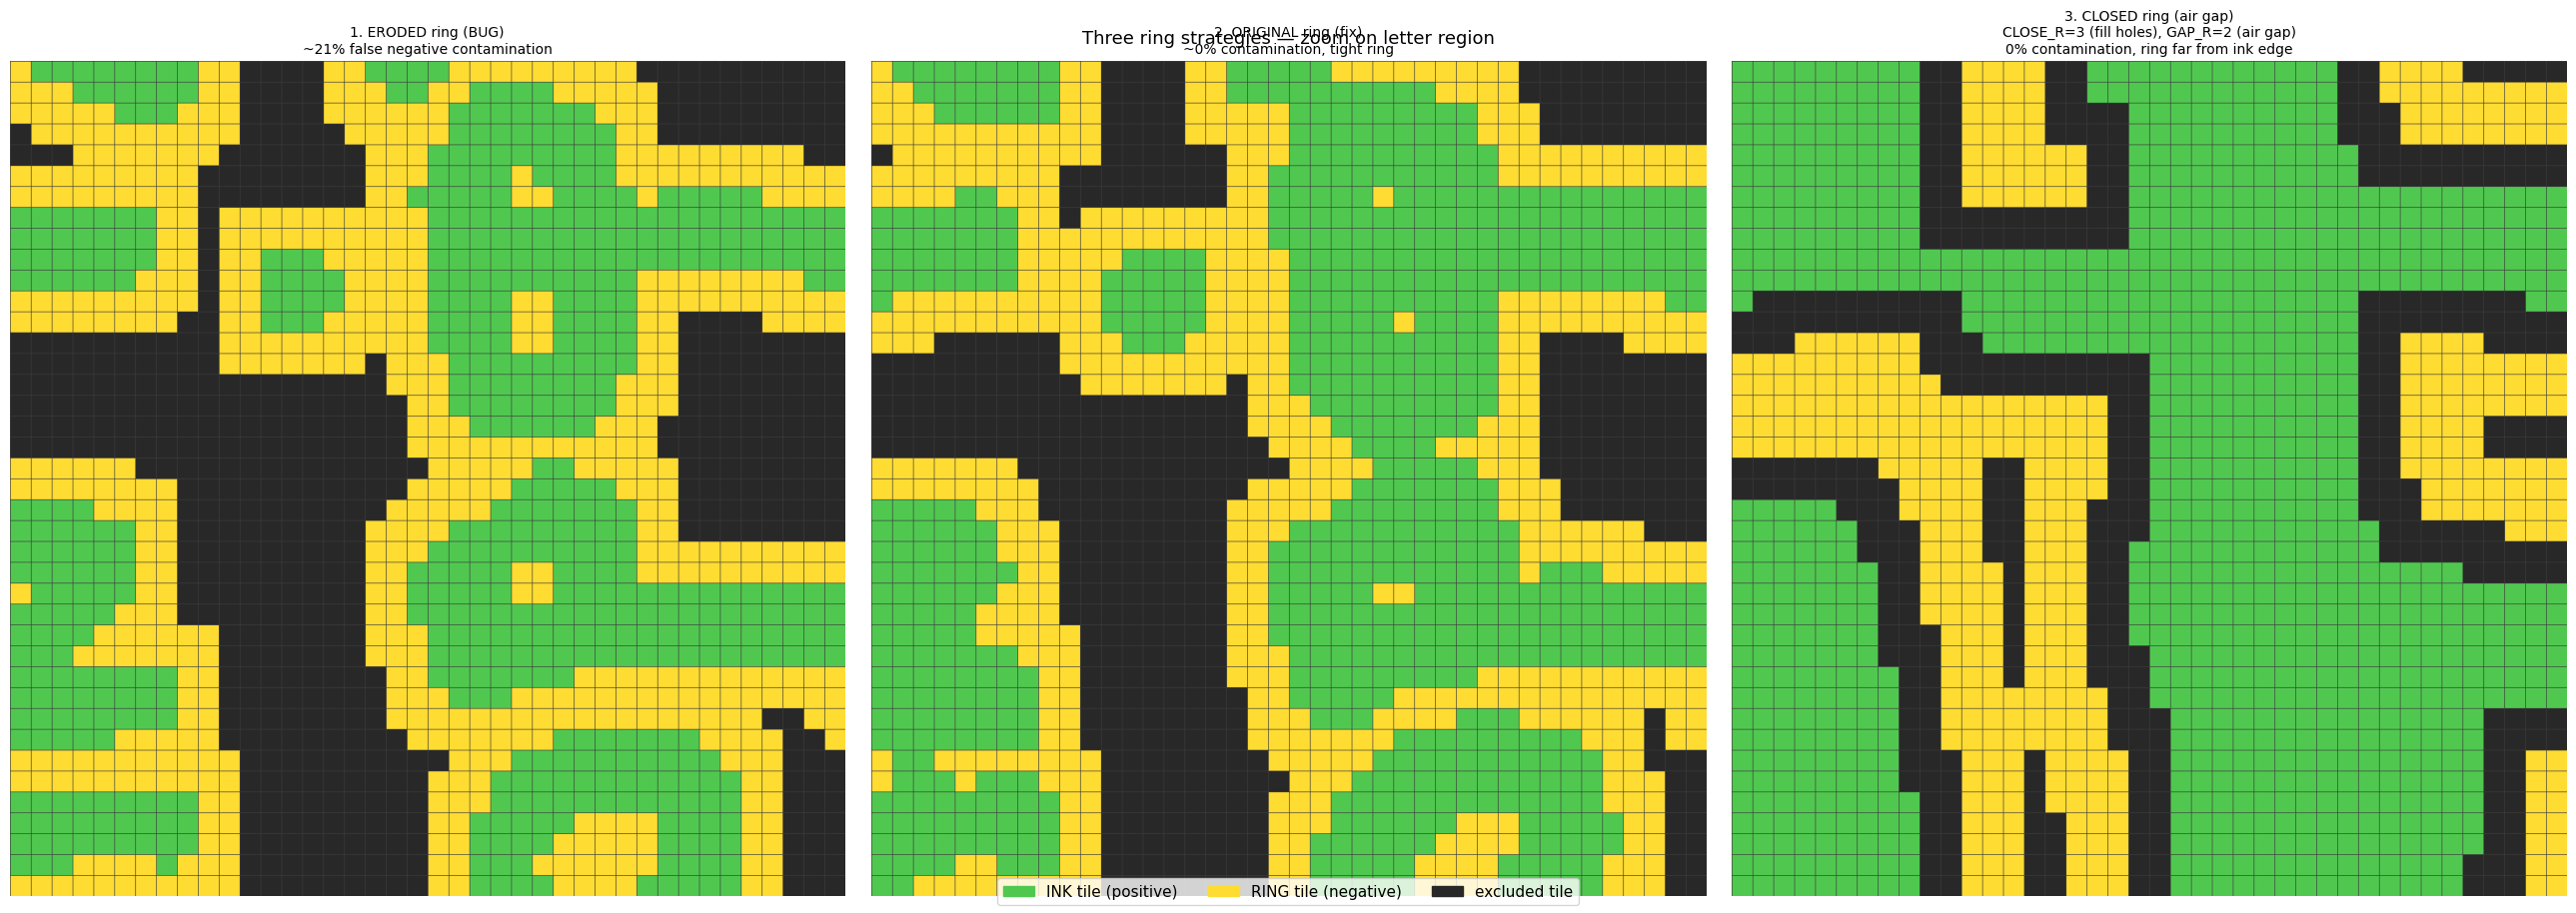

In [10]:

# visualize all three ring variants side by side
rgb_closed = make_rgb_map(ink_closed, ring_closed, y0, y1, x0, x1)

fig, axes = plt.subplots(1, 3, figsize=(26, 9))
for ax, rgb, title in zip(axes,
        [rgb_ero, rgb_orig, rgb_closed],
        ['1. ERODED ring (BUG)\n~21% false negative contamination',
         '2. ORIGINAL ring (fix)\n~0% contamination, tight ring',
         f'3. CLOSED ring (air gap)\nCLOSE_R={CLOSE_R} (fill holes), GAP_R={GAP_R} (air gap)\n0% contamination, ring far from ink edge']):
    ax.imshow(rgb)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

patches = [
    mpatches.Patch(color=[80/255,200/255,80/255], label='INK tile (positive)'),
    mpatches.Patch(color=[255/255,220/255,50/255], label='RING tile (negative)'),
    mpatches.Patch(color=[40/255,40/255,40/255], label='excluded tile'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11)
plt.suptitle('Three ring strategies — zoom on letter region', fontsize=13)
plt.tight_layout()
plt.show()


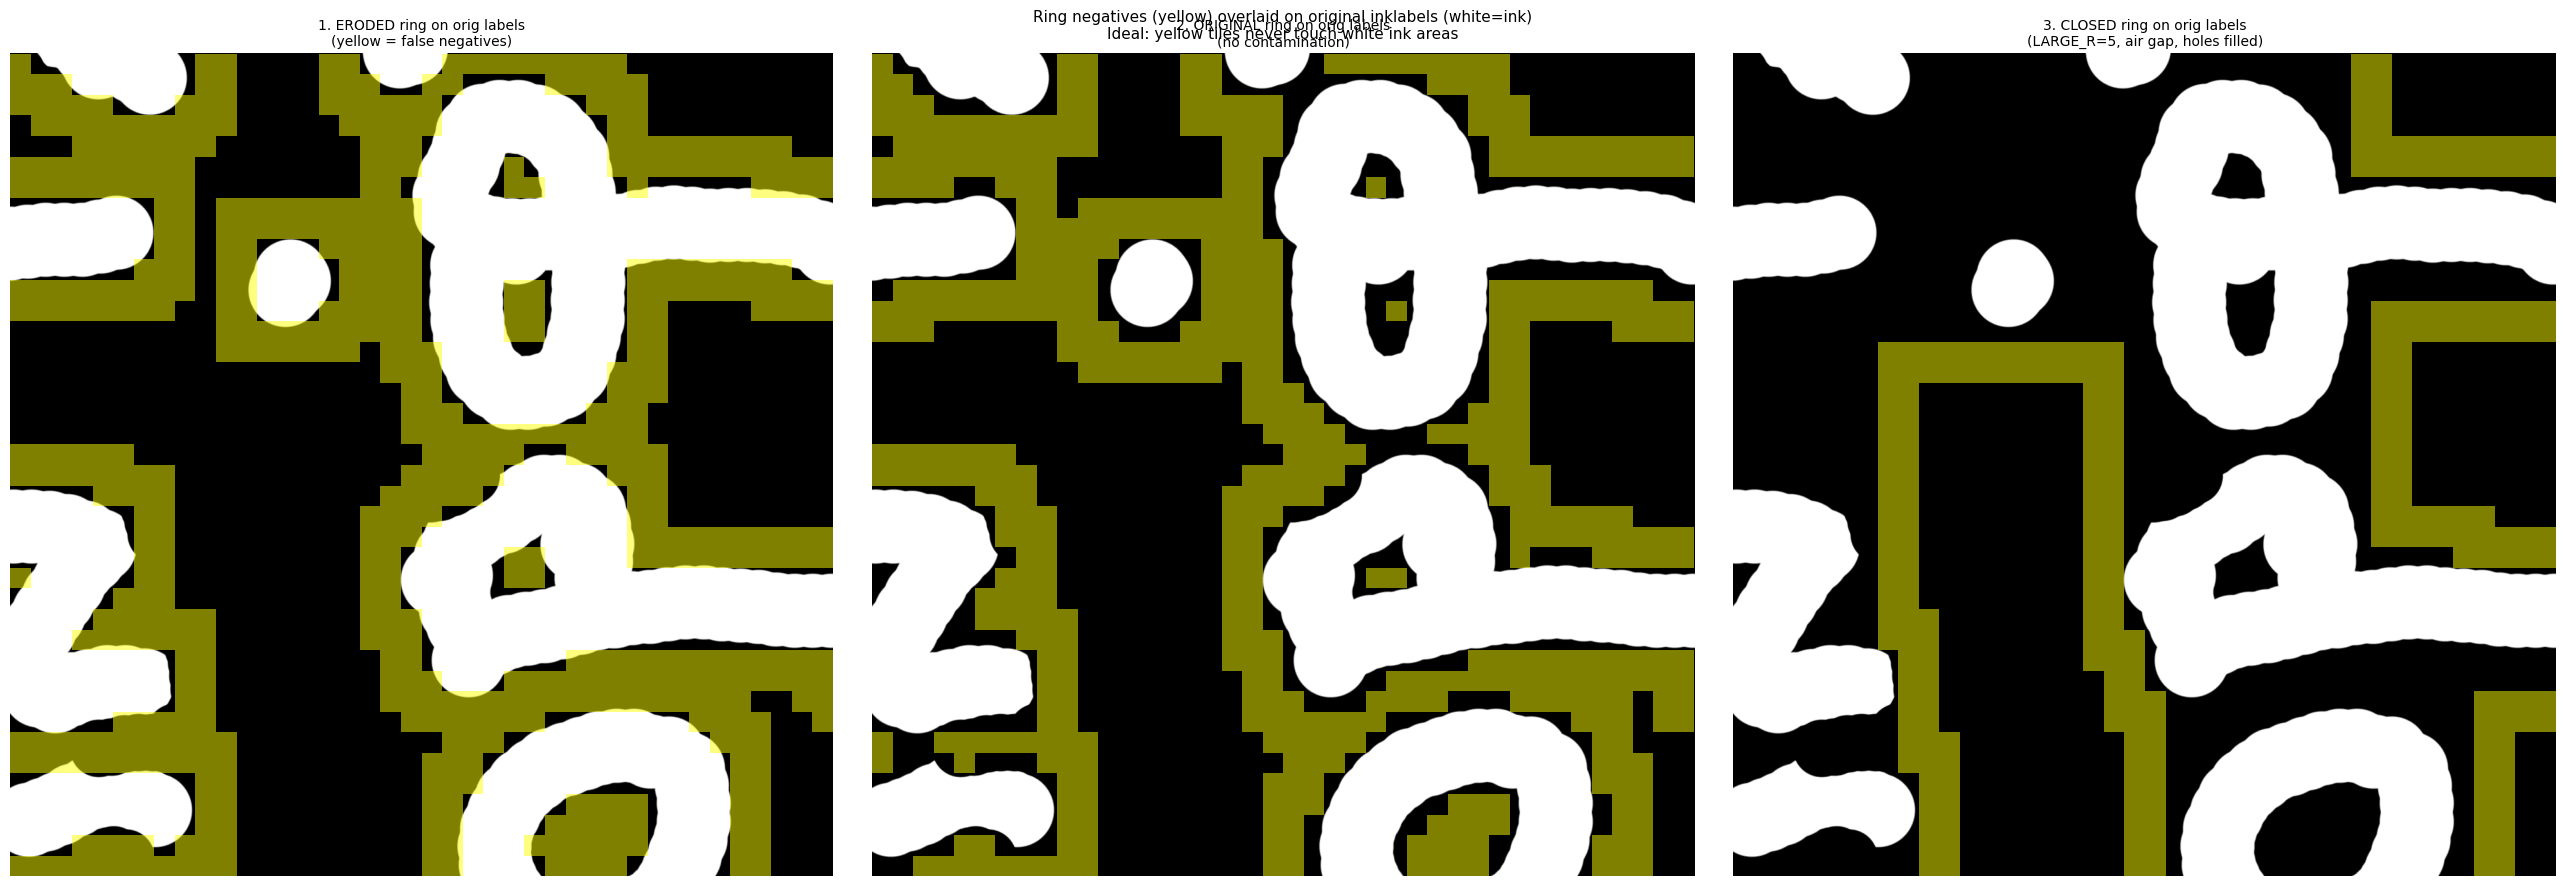

In [ ]:

# overlay of closed ring on original labels
fig, axes = plt.subplots(1, 3, figsize=(26, 9))
zoom_px = (y0*T, y1*T, x0*T, x1*T)

overlay_ring(orig, ring_ero,    axes[0], '1. ERODED ring on orig labels\n(yellow = false negatives)')
overlay_ring(orig, ring_orig,   axes[1], '2. ORIGINAL ring on orig labels\n(no contamination)')
overlay_ring(orig, ring_closed, axes[2], f'3. CLOSED ring — CLOSE_R={CLOSE_R}, GAP_R={GAP_R}\n(yellow tiles have air gap from all ink)')
plt.suptitle('Ring negatives (yellow) overlaid on original inklabels (white=ink)\nIdeal: yellow tiles never touch white ink areas', fontsize=11)
plt.tight_layout()
plt.show()


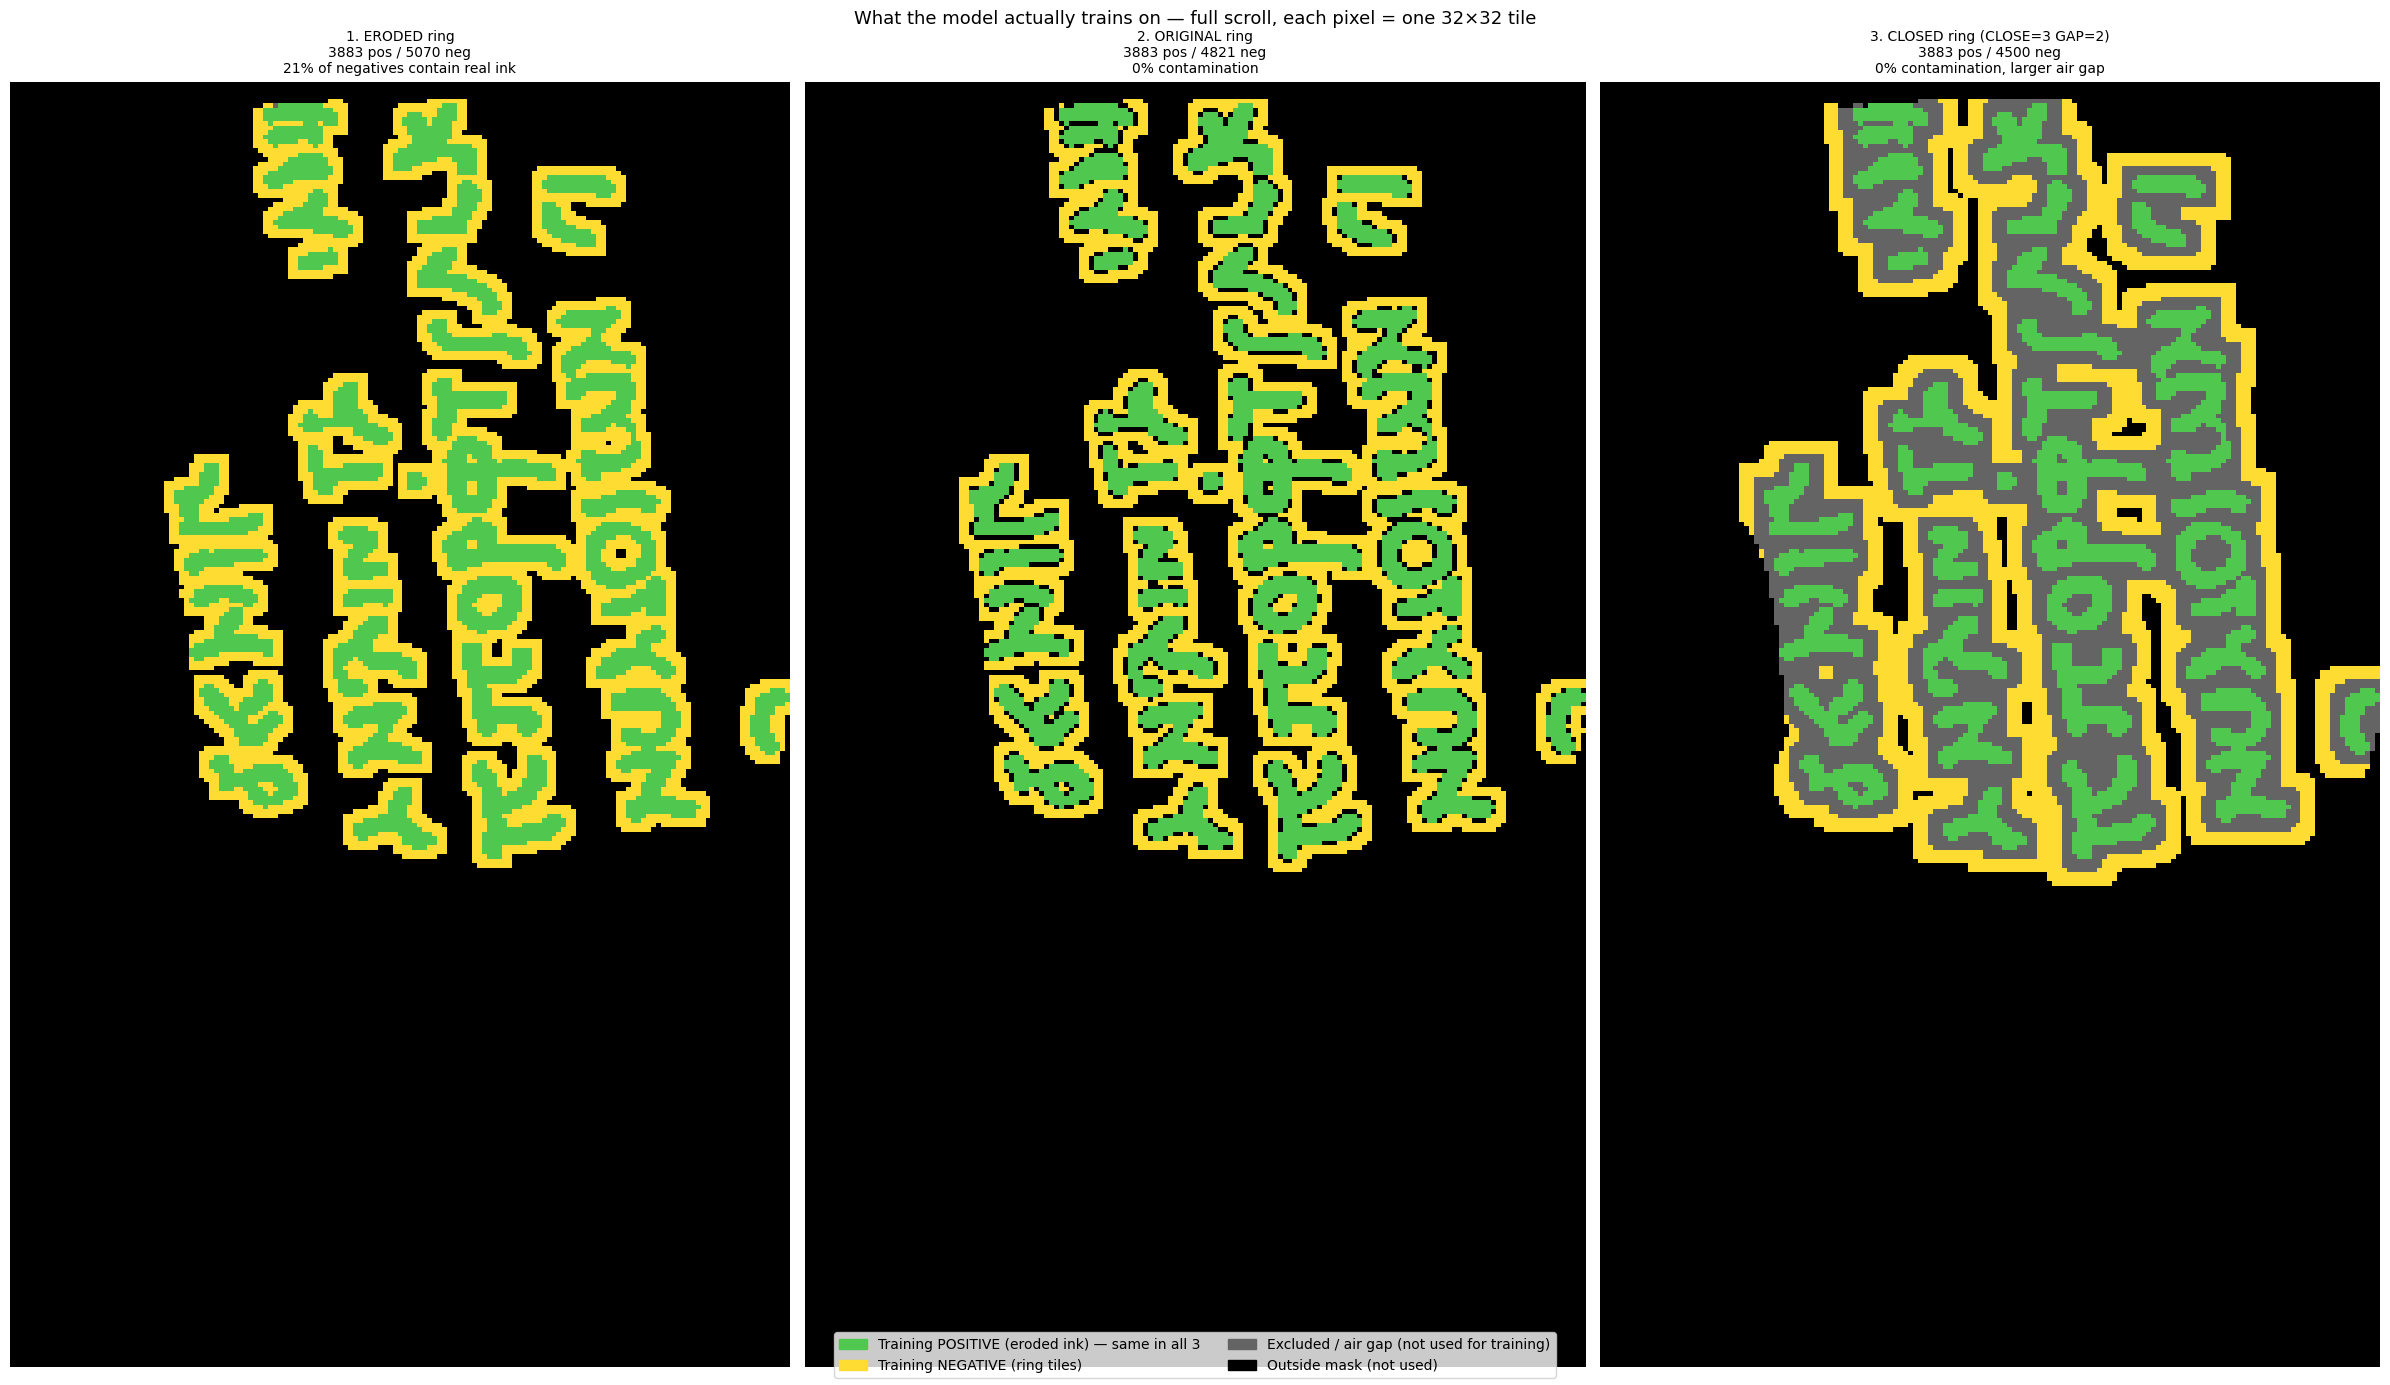

: 

In [ ]:

# fully zoomed-out view — showing WHAT THE MODEL ACTUALLY TRAINS ON
#
# Colors:
#   GREEN  = training POSITIVES (eroded ink tiles — same for all three variants)
#   YELLOW = training NEGATIVES (ring tiles — differs per variant)
#   GRAY   = exclusion zone (not used for training: air gap or closed-blob interior)
#   BLACK  = outside mask, also excluded
#
# The closed ring's large green exclusion zone is NOT trained on — it is
# only used to determine where the ring boundary starts.

def make_training_map(ink_pos, ring_neg, exclusion_zone=None):
    """
    ink_pos:        tiles used as positive training examples (always eroded ink)
    ring_neg:       tiles used as negative training examples
    exclusion_zone: tiles that are excluded (not ink_pos, not ring_neg) shown in gray
    """
    img = np.zeros((n_ty, n_tx, 3), np.uint8)
    for ty in range(n_ty):
        for tx in range(n_tx):
            if ink_pos[ty, tx]:
                img[ty, tx] = [80, 200, 80]    # green  = positive
            elif ring_neg[ty, tx]:
                img[ty, tx] = [255, 220, 50]   # yellow = negative ring
            elif exclusion_zone is not None and exclusion_zone[ty, tx]:
                img[ty, tx] = [100, 100, 100]  # gray   = excluded (air gap / closed zone)
    return img

# for eroded/original: exclusion zone = ink tiles not in eroded (boundary tiles)
excl_ero  = np.clip(ink_orig.astype(int) - ink_ero.astype(int), 0, 1).astype(np.uint8)
excl_orig = np.zeros_like(ink_orig)  # no exclusion for original ring

# for closed: exclusion zone = (ink_closed union its air gap) minus (eroded ink + ring)
excl_closed = np.clip(
    exclusion_final.astype(int)               # full exclusion blob
    - ink_ero.astype(int)                     # minus actual positives
    - ring_closed.astype(int),                # minus the ring negatives
    0, 1
).astype(np.uint8)

full_ero    = make_training_map(ink_ero, ring_ero,    excl_ero)
full_orig   = make_training_map(ink_ero, ring_orig,   excl_orig)
full_closed = make_training_map(ink_ero, ring_closed, excl_closed)

fig, axes = plt.subplots(1, 3, figsize=(24, 14))
for ax, img, title in zip(axes,
        [full_ero, full_orig, full_closed],
        [f'1. ERODED ring\n{ink_ero.sum()} pos / {ring_ero.sum()} neg\n21% of negatives contain real ink',
         f'2. ORIGINAL ring\n{ink_ero.sum()} pos / {ring_orig.sum()} neg\n0% contamination',
         f'3. CLOSED ring (CLOSE={CLOSE_R} GAP={GAP_R})\n{ink_ero.sum()} pos / {ring_closed.sum()} neg\n0% contamination, larger air gap']):
    ax.imshow(img, interpolation='nearest', aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

patches = [
    mpatches.Patch(color=[80/255,  200/255, 80/255],  label='Training POSITIVE (eroded ink) — same in all 3'),
    mpatches.Patch(color=[255/255, 220/255, 50/255],  label='Training NEGATIVE (ring tiles)'),
    mpatches.Patch(color=[100/255, 100/255, 100/255], label='Excluded / air gap (not used for training)'),
    mpatches.Patch(color=[0, 0, 0],                   label='Outside mask (not used)'),
]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=10)
plt.suptitle('What the model actually trains on — full scroll, each pixel = one 32×32 tile', fontsize=13)
plt.tight_layout()
plt.show()
